In [2]:
!pip install librosa tensorflow scikit-learn matplotlib

In [2]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [8]:
DATASET_PATH = "..\dataset"
SAMPLE_RATE = 16000
DURATION = 3
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

In [9]:
def load_data():
    X, y = [], []

    for label, folder in enumerate(["real", "fake"]):
        path = os.path.join(DATASET_PATH, folder)

        for file in os.listdir(path):
            file_path = os.path.join(path, file)

            try:
                audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)

                if len(audio) < SAMPLES_PER_TRACK:
                    audio = np.pad(audio, (0, SAMPLES_PER_TRACK - len(audio)))
                else:
                    audio = audio[:SAMPLES_PER_TRACK]

                mel = librosa.feature.melspectrogram(y=audio, sr=sr)
                mel_db = librosa.power_to_db(mel, ref=np.max)

                mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-6)

                X.append(mel_db)
                y.append(label)

            except:
                continue

    X = np.array(X)
    y = np.array(y)

    X = X[..., np.newaxis]

    X = np.repeat(X, 3, axis=-1)

    return train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
X_train, X_test, y_train, y_test = load_data()

print("Train shape:", X_train.shape)

Train shape: (11164, 128, 94, 3)


Model 1:


In [11]:
def build_cnn(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [12]:
cnn_model = build_cnn(X_train.shape[1:])
cnn_model.fit(X_train, y_train, epochs=10, batch_size=16)

cnn_pred = (cnn_model.predict(X_test) > 0.5).astype(int)
cnn_acc = accuracy_score(y_test, cnn_pred)

print("CNN Accuracy:", cnn_acc)

Epoch 1/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 53s 73ms/step - accuracy: 0.7410 - loss: 0.6104
Epoch 2/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.9332 - loss: 0.2273
Epoch 3/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.9631 - loss: 0.0954
Epoch 4/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.9725 - loss: 0.0674
Epoch 5/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.9777 - loss: 0.0626
Epoch 6/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.9787 - loss: 0.0577
Epoch 7/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.9827 - loss: 0.0473
Epoch 8/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.9851 - loss: 0.0472
Epoch 9/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.9874 - loss: 0.0412
Epoch 10/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 51s 74ms/step - accuracy: 0.9904 - loss: 0.0329
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
CNN Accuracy: 0.9831661891117478


Model 2:


In [9]:
def build_cnn2(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [10]:
cnn2_model = build_cnn2(X_train.shape[1:])
cnn2_model.fit(X_train, y_train, epochs=10, batch_size=16)

cnn2_pred = (cnn2_model.predict(X_test) > 0.5).astype(int)
cnn2_acc = accuracy_score(y_test, cnn2_pred)

print("CNN2 Accuracy:", cnn2_acc)

e:\Anaconda\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.8741 - loss: 0.4106
Epoch 2/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.9775 - loss: 0.0671
Epoch 3/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9877 - loss: 0.0369
Epoch 4/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9970 - loss: 0.0123
Epoch 5/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9903 - loss: 0.0252
Epoch 6/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9854 - loss: 0.0425
Epoch 7/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9978 - loss: 0.0077
Epoch 8/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9944 - loss: 0.0172
Epoch 9/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9953 - loss: 0.0163
Epoch 10/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9990 - loss: 0.0030
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
CNN2 Accuracy: 0.9953438395415473


Model 3:

In [11]:
def build_lstm(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Reshape((input_shape[0], input_shape[1]*input_shape[2])),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [12]:
lstm_model = build_lstm(X_train.shape[1:])
lstm_model.fit(X_train, y_train, epochs=10, batch_size=16)

lstm_pred = (lstm_model.predict(X_test) > 0.5)
lstm_acc = accuracy_score(y_test, lstm_pred)

print("LSTM Accuracy:", lstm_acc)

Epoch 1/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.6994 - loss: 0.5850
Epoch 2/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.7753 - loss: 0.4651
Epoch 3/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.8478 - loss: 0.3278
Epoch 4/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.8758 - loss: 0.2784
Epoch 5/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.8858 - loss: 0.2580
Epoch 6/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8907 - loss: 0.2505
Epoch 7/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9085 - loss: 0.2197
Epoch 8/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.9161 - loss: 0.2001
Epoch 9/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.9164 - loss: 0.1962
Epoch 10/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.9303 - loss: 0.1699
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
LSTM Accuracy: 0.9151146131805158


MobileNet

In [13]:
from tensorflow.keras.applications import MobileNetV2

def build_mobilenet(input_shape):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights=None)

    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=base.input, outputs=output)

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [14]:
mobilenet_model = build_mobilenet(X_train.shape[1:])
mobilenet_model.fit(X_train, y_train, epochs=10, batch_size=16)

mobilenet_pred = (mobilenet_model.predict(X_test) > 0.5)
mobilenet_acc = accuracy_score(y_test, mobilenet_pred)

print("MobileNet Accuracy:", mobilenet_acc)

Epoch 1/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 124s 140ms/step - accuracy: 0.8805 - loss: 0.2682
Epoch 2/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 102s 145ms/step - accuracy: 0.9719 - loss: 0.0858
Epoch 3/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 100s 144ms/step - accuracy: 0.9822 - loss: 0.0533
Epoch 4/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 104s 150ms/step - accuracy: 0.9842 - loss: 0.0432
Epoch 5/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 123s 176ms/step - accuracy: 0.9915 - loss: 0.0266
Epoch 6/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 142s 203ms/step - accuracy: 0.9888 - loss: 0.0347
Epoch 7/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 141s 201ms/step - accuracy: 0.9930 - loss: 0.0222
Epoch 8/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 143s 205ms/step - accuracy: 0.9886 - loss: 0.0326
Epoch 9/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 142s 204ms/step - accuracy: 0.9927 - loss: 0.0228
Epoch 10/10
698/698 ━━━━━━━━━━━━━━━━━━━━ 133s 191ms/step - accuracy: 0.9940 - loss: 0.0216
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step
MobileNet Accuracy: 0.9255014326647565


Ensemble:

In [15]:
ensemble_pred = (
    0.4 * mobilenet_model.predict(X_test) +
    0.3 * lstm_model.predict(X_test) +
    0.2 * cnn_model.predict(X_test) +
    0.1 * cnn2_model.predict(X_test)
) > 0.5

ensemble_acc = accuracy_score(y_test, ensemble_pred)

print("Final Ensemble Accuracy:", ensemble_acc)

88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Final Ensemble Accuracy: 0.9376790830945558


In [16]:
print("\n📊 FINAL COMPARISON")
print("----------------------")
print(f"CNN Accuracy:            {cnn_acc:.4f}")
print(f"CNN2 Accuracy:           {cnn2_acc:.4f}")
print(f"LSTM Accuracy:           {lstm_acc:.4f}")
print(f"Mobilenet Accuracy:      {mobilenet_acc:.4f}")
print(f"Ensemble Accuracy:       {ensemble_acc:.4f}")


📊 FINAL COMPARISON
----------------------
CNN Accuracy:            0.4961
CNN2 Accuracy:           0.9953
LSTM Accuracy:           0.9151
Mobilenet Accuracy:      0.9255
Ensemble Accuracy:       0.9377


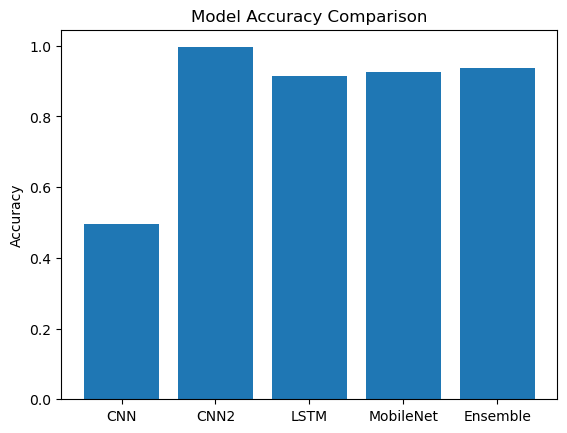

In [17]:
import matplotlib.pyplot as plt

plt.bar(
    ["CNN", "CNN2", "LSTM", "MobileNet", "Ensemble"],
    [cnn_acc, cnn2_acc, lstm_acc, mobilenet_acc, ensemble_acc]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [18]:
print(cnn_acc, cnn2_acc, lstm_acc, mobilenet_acc, ensemble_acc)

0.49606017191977075 0.9953438395415473 0.9151146131805158 0.9255014326647565 0.9376790830945558


In [19]:
ensemble_pred = (
    0.5 * mobilenet_model.predict(X_test) +
    0.3 * cnn_model.predict(X_test) +
    0.2 * cnn2_model.predict(X_test)
) > 0.5

ensemble_acc = accuracy_score(y_test, ensemble_pred)

print("Final Ensemble Accuracy:", ensemble_acc)

88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Final Ensemble Accuracy: 0.9283667621776505


In [20]:
ensemble_pred = (
    0.7 * cnn_model.predict(X_test) +
    0.3 * cnn2_model.predict(X_test)
) > 0.5

ensemble_acc = accuracy_score(y_test, ensemble_pred)

print("Final Ensemble Accuracy:", ensemble_acc)

88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Final Ensemble Accuracy: 0.9953438395415473


In [21]:
# Save as TensorFlow SavedModel (if not already done)
cnn_model.save("final_model.keras")

In [22]:
train_pred = (cnn_model.predict(X_train) > 0.5)
train_acc = accuracy_score(y_train, train_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", cnn_acc)

349/349 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step
Train Accuracy: 0.5016123253314224
Test Accuracy: 0.49606017191977075


In [25]:
cnn_model.save("models/cnn1.keras")
cnn2_model.save("models/cnn2.keras")
lstm_model.save("models/lstm.keras")
mobilenet_model.save("models/mobilenet.keras")

In [14]:
cnn_model.save("..\models/cnn1.keras")
